In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colorbar import ColorbarBase

# --- Colormaps parsed from colors.cpp ---
# Each is a list of (R, G, B) tuples, index 0..255

import re

def parse_colormaps(cpp_path):
    """Parse all Colormap definitions from colors.cpp.
    Returns a dict of {name: np.array of shape (256, 3), dtype=uint8}.
    """
    with open(cpp_path) as f:
        text = f.read()

    # Match: identifier followed by = { {r,g,b}, ... };
    pattern = re.compile(
        r'(\w+)\s*=\s*\{\s*([^;]+?)\s*\}\s*;',
        re.DOTALL
    )
    triple_pattern = re.compile(r'\{\s*(\d+)\s*,\s*(\d+)\s*,\s*(\d+)\s*\}')

    colormaps = {}
    for m in pattern.finditer(text):
        name = m.group(1)
        body = m.group(2)
        triples = triple_pattern.findall(body)
        if len(triples) == 256:
            arr = np.array([[int(r), int(g), int(b)] for r, g, b in triples], dtype=np.uint8)
            colormaps[name] = arr
    return colormaps

COLORMAPS = parse_colormaps('cpp/FillDEM/colors.cpp')
print('Found colormaps:', list(COLORMAPS.keys()))

Found colormaps: ['plasma_reverse_colormap', 'rainbow_4_reverse_colormap', 'viridis_reverse_colormap', 'spring_reverse_colormap', 'winter_reverse_colormap', 'cool_colormap', 'gist_rainbow_colormap']


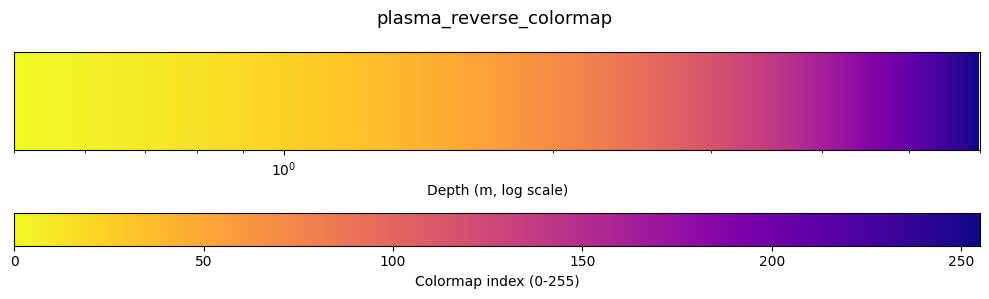

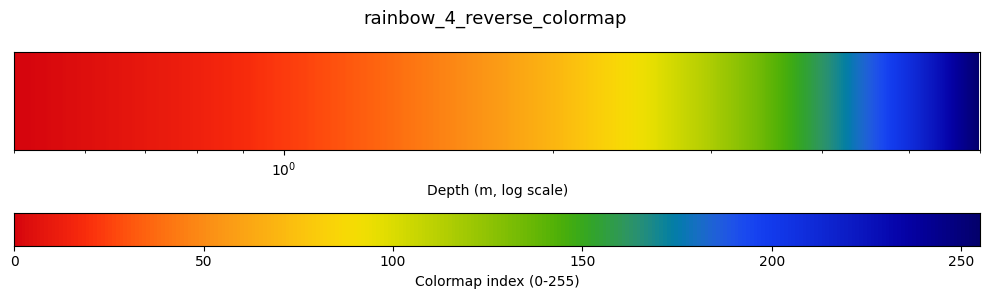

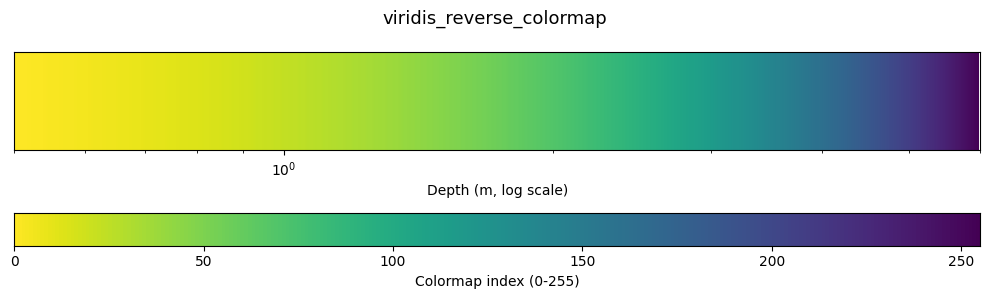

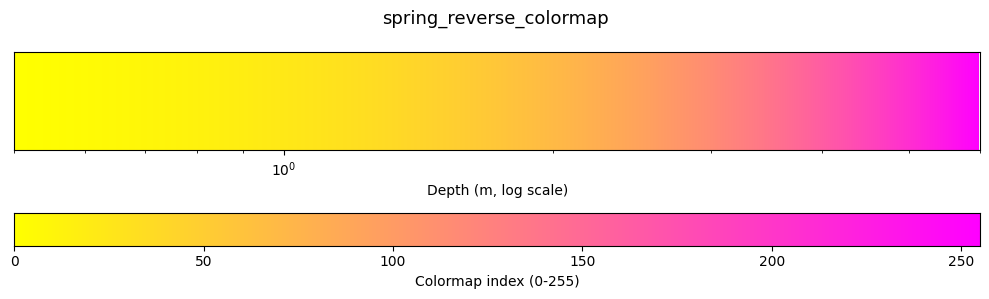

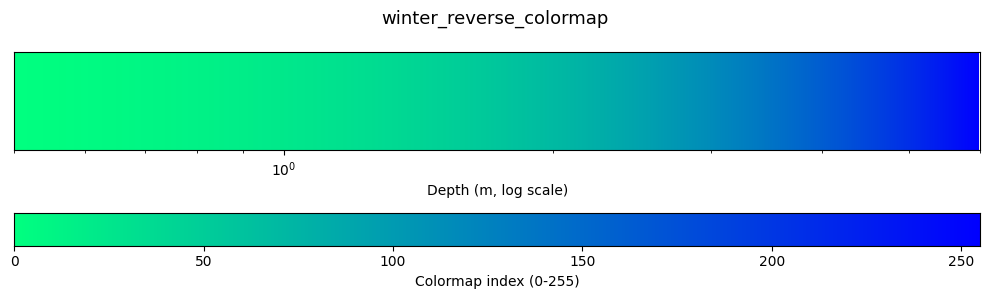

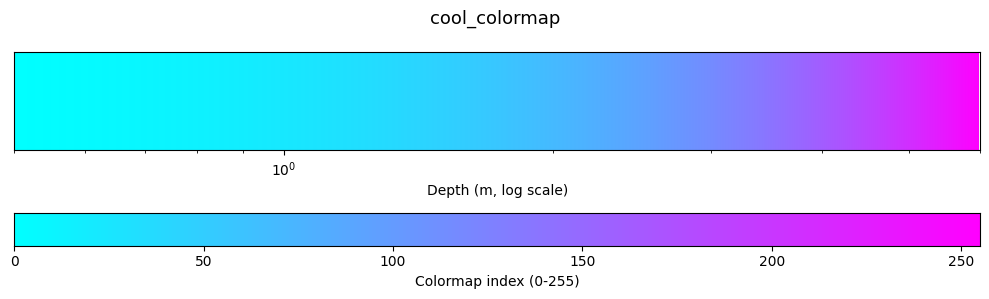

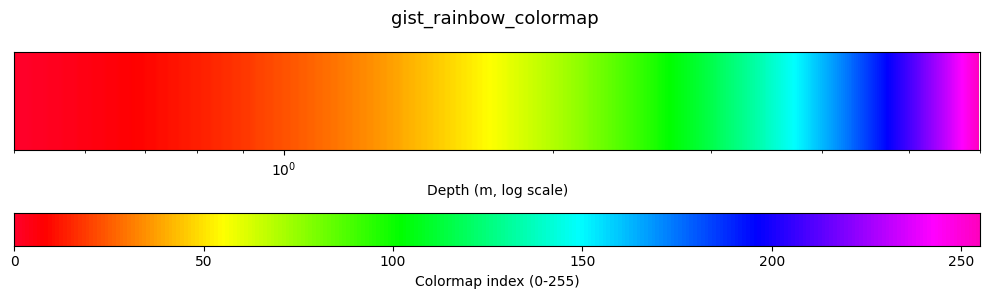

In [3]:
# --- Settings (match defaults in settings.h) ---
MIN_DEPTH = 0.5   # DEFAULT_MIN_DEPTH_FOR_COLORMAP
MAX_DEPTH = 6.0   # DEFAULT_MAX_DEPTH_FOR_COLORMAP

def depth_to_color(depth, colormap, min_depth=MIN_DEPTH, max_depth=MAX_DEPTH):
    """Mirrors Settings::depth_to_color from settings.cpp.
    Uses a log scale between min_depth and max_depth.
    Returns an (R, G, B) tuple of uint8.
    """
    depth = np.clip(depth, min_depth, max_depth)
    log_min = np.log(min_depth)
    log_max = np.log(max_depth)
    normalized = (np.log(depth) - log_min) / (log_max - log_min)
    index = int(np.clip(normalized * 256, 0, 255))
    return colormap[index]


def plot_colormap(colormap_name, min_depth=MIN_DEPTH, max_depth=MAX_DEPTH, n_samples=500):
    colormap = COLORMAPS[colormap_name]

    # Sample depths on a log scale to match how the colormap is actually applied
    depths = np.exp(np.linspace(np.log(min_depth), np.log(max_depth), n_samples))
    colors = np.array([depth_to_color(d, colormap, min_depth, max_depth) for d in depths])

    # Build a matplotlib colormap from the RGB array for the colorbar
    rgb_normalized = colormap / 255.0
    mpl_cmap = mcolors.ListedColormap(rgb_normalized)

    fig, axes = plt.subplots(2, 1, figsize=(10, 3),
                             gridspec_kw={'height_ratios': [3, 1]})
    fig.suptitle(colormap_name, fontsize=13)

    # Top: color strip showing depth -> color mapping on a log axis
    ax = axes[0]
    ax.imshow(
        colors[np.newaxis, :, :],
        aspect='auto',
        extent=[min_depth, max_depth, 0, 1]
    )
    ax.set_xscale('log')
    ax.set_xlabel('Depth (m, log scale)')
    ax.set_yticks([])

    # Bottom: the raw colormap index order (0-255)
    ax2 = axes[1]
    ax2.imshow(
        rgb_normalized[np.newaxis, :, :],
        aspect='auto',
        extent=[0, 255, 0, 1]
    )
    ax2.set_xlabel('Colormap index (0-255)')
    ax2.set_yticks([])

    plt.tight_layout()
    plt.show()


# Plot all colormaps
for name in COLORMAPS:
    plot_colormap(name)

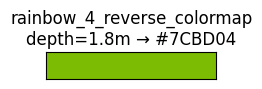

In [6]:
# --- Look up the color for a specific depth ---
COLORMAP_NAME = 'rainbow_4_reverse_colormap'  # change as needed
DEPTH = 1.8  # meters

color = depth_to_color(DEPTH, COLORMAPS[COLORMAP_NAME])
hex_color = '#{:02X}{:02X}{:02X}'.format(*color)

fig, ax = plt.subplots(figsize=(2, 1))
ax.set_facecolor(hex_color)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title(f'{COLORMAP_NAME}\ndepth={DEPTH}m → {hex_color}')
plt.tight_layout()
plt.show()